# Day 3: Statistics & Probability for ML

**Dataset:** Titanic cleaned (from Day 2)
**Goal:** Confidence intervals, t-tests, chi-square tests, p-value interpretation

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import math

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 200)

# Load cleaned data
df = pd.read_csv('../data/titanic_clean.csv')
print(f"Loaded: {df.shape}")
df.head()

Loaded: (891, 19)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,family_size,is_alone,fare_per_person,age_bin
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Unknown,Southampton,no,False,2,0,3.62500,Young Adult
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False,2,0,35.64165,Adult
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Unknown,Southampton,yes,True,1,1,7.92500,Young Adult
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False,2,0,26.55000,Young Adult
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Unknown,Southampton,no,True,1,1,8.05000,Young Adult


In [2]:
# 1. CONFIDENCE INTERVALS
def ci_mean(series, confidence=0.95):
    """95% CI for mean using t-distribution"""
    n = len(series)
    mean = series.mean()
    se = series.std() / math.sqrt(n)
    t = stats.t.ppf((1 + confidence) / 2, n - 1)
    return mean - t * se, mean + t * se

# Overall
print("=== 95% CI for Overall Means ===")
for col in ['age', 'fare']:
    low, high = ci_mean(df[col])
    print(f"{col}: [{low:.2f}, {high:.2f}] (mean={df[col].mean():.2f})")

# By survival status
print("\n=== 95% CI for Means by Survival ===")
for col in ['age', 'fare']:
    for survived_val in [0, 1]:
        subset = df[df['survived'] == survived_val][col]
        low, high = ci_mean(subset)
        label = 'Died' if survived_val == 0 else 'Survived'
        print(f"{col} | {label}: [{low:.2f}, {high:.2f}] (mean={subset.mean():.2f}, n={len(subset)})")

=== 95% CI for Overall Means ===
age: [28.24, 29.99] (mean=29.11)
fare: [28.94, 35.47] (mean=32.20)

=== 95% CI for Means by Survival ===
age | Died: [28.66, 30.81] (mean=29.74, n=549)
age | Survived: [26.62, 29.60] (mean=28.11, n=342)
fare | Died: [19.49, 24.75] (mean=22.12, n=549)
fare | Survived: [41.31, 55.48] (mean=48.40, n=342)


In [3]:
# 2. T-TESTS: numeric features vs survival
print("=== Independent T-Tests (numeric features vs survived) ===")

for col in ['age', 'fare', 'sibsp', 'parch', 'family_size', 'fare_per_person']:
    survived_vals = df[df['survived'] == 1][col].dropna()
    died_vals = df[df['survived'] == 0][col].dropna()
    
    # Welch's t-test (doesn't assume equal variance)
    t_stat, p_val = stats.ttest_ind(survived_vals, died_vals, equal_var=False)
    
    # Effect size: Cohen's d
    pooled_std = math.sqrt((survived_vals.var() + died_vals.var()) / 2)
    cohens_d = (survived_vals.mean() - died_vals.mean()) / pooled_std if pooled_std > 0 else 0
    
    print(f"{col}: t={t_stat:.3f}, p={p_val:.6f}, Cohen's d={cohens_d:.3f}")
    print(f"  Survived mean={survived_vals.mean():.2f}, Died mean={died_vals.mean():.2f}")

=== Independent T-Tests (numeric features vs survived) ===
age: t=-1.743, p=0.081747, Cohen's d=-0.121
  Survived mean=28.11, Died mean=29.74
fare: t=6.839, p=0.000000, Cohen's d=0.505
  Survived mean=48.40, Died mean=22.12
sibsp: t=-1.194, p=0.232663, Cohen's d=-0.077
  Survived mean=0.47, Died mean=0.55
parch: t=2.479, p=0.013395, Cohen's d=0.169
  Survived mean=0.46, Died mean=0.33
family_size: t=0.546, p=0.585335, Cohen's d=0.036
  Survived mean=1.94, Died mean=1.88
fare_per_person: t=5.668, p=0.000000, Cohen's d=0.424
  Survived mean=29.97, Died mean=13.65


In [4]:
# 3. CHI-SQUARE TESTS: categorical features vs survival
print("=== Chi-Square Tests (categorical features vs survived) ===")

cat_cols = ['sex', 'pclass', 'embarked', 'deck', 'who', 'embark_town', 'age_bin', 'is_alone']

for col in cat_cols:
    # Create contingency table
    crosstab = pd.crosstab(df[col], df['survived'])
    
    # Chi-square test
    chi2, p_val, dof, expected = stats.chi2_contingency(crosstab)
    
    # Effect size: Cramér's V
    n = crosstab.sum().sum()
    min_dim = min(crosstab.shape) - 1
    cramers_v = math.sqrt(chi2 / (n * min_dim)) if min_dim > 0 else 0
    
    print(f"{col}: χ²={chi2:.2f}, p={p_val:.6f}, Cramér's V={cramers_v:.3f}, dof={dof}")
    
    # Show survival rates per category
    surv_rates = crosstab[1] / (crosstab[0] + crosstab[1])
    print(f"  Survival rates: {surv_rates.to_dict()}")

=== Chi-Square Tests (categorical features vs survived) ===
sex: χ²=260.72, p=0.000000, Cramér's V=0.541, dof=1
  Survival rates: {'female': 0.7420382165605095, 'male': 0.18890814558058924}
pclass: χ²=102.89, p=0.000000, Cramér's V=0.340, dof=2
  Survival rates: {1: 0.6296296296296297, 2: 0.47282608695652173, 3: 0.24236252545824846}
embarked: χ²=25.96, p=0.000002, Cramér's V=0.171, dof=2
  Survival rates: {'C': 0.5535714285714286, 'Q': 0.38961038961038963, 'S': 0.33900928792569657}
deck: χ²=98.78, p=0.000000, Cramér's V=0.333, dof=7
  Survival rates: {'A': 0.4666666666666667, 'B': 0.7446808510638298, 'C': 0.5932203389830508, 'D': 0.7575757575757576, 'E': 0.75, 'F': 0.6153846153846154, 'G': 0.5, 'Unknown': 0.29941860465116277}
who: χ²=283.92, p=0.000000, Cramér's V=0.564, dof=2
  Survival rates: {'child': 0.5903614457831325, 'man': 0.16387337057728119, 'woman': 0.7564575645756457}
embark_town: χ²=25.96, p=0.000002, Cramér's V=0.171, dof=2
  Survival rates: {'Cherbourg': 0.55357142857142

=== P-Value Interpretation ===
Proportion p < 0.05 under null: 0.0490
Proportion p < 0.01 under null: 0.0093

Proportion p < 0.05 with true diff: 0.5102 (power)
Proportion p < 0.01 with true diff: 0.2804


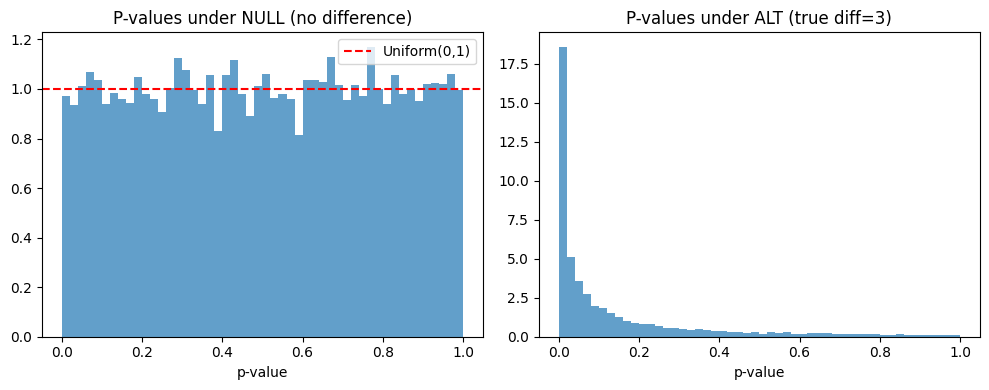

In [5]:
# 4. P-VALUE INTERPRETATION DEMO
print("=== P-Value Interpretation ===")

# Simulate: what if there's NO difference? (null hypothesis true)
np.random.seed(42)
n_sim = 10000
p_values_null = []

for _ in range(n_sim):
    # Two groups from SAME distribution
    g1 = np.random.normal(30, 15, 200)
    g2 = np.random.normal(30, 15, 200)
    _, p = stats.ttest_ind(g1, g2)
    p_values_null.append(p)

# Under null, p-values should be UNIFORM(0,1)
print(f"Proportion p < 0.05 under null: {(np.array(p_values_null) < 0.05).mean():.4f}")
print(f"Proportion p < 0.01 under null: {(np.array(p_values_null) < 0.01).mean():.4f}")

# Now with a REAL difference (alternative hypothesis)
p_values_alt = []
for _ in range(n_sim):
    g1 = np.random.normal(30, 15, 200)
    g2 = np.random.normal(33, 15, 200)  # True diff = 3
    _, p = stats.ttest_ind(g1, g2)
    p_values_alt.append(p)

print(f"\nProportion p < 0.05 with true diff: {(np.array(p_values_alt) < 0.05).mean():.4f} (power)")
print(f"Proportion p < 0.01 with true diff: {(np.array(p_values_alt) < 0.01).mean():.4f}")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(p_values_null, bins=50, alpha=0.7, density=True)
axes[0].axhline(1, color='red', linestyle='--', label='Uniform(0,1)')
axes[0].set_title('P-values under NULL (no difference)')
axes[0].set_xlabel('p-value')
axes[0].legend()

axes[1].hist(p_values_alt, bins=50, alpha=0.7, density=True)
axes[1].set_title('P-values under ALT (true diff=3)')
axes[1].set_xlabel('p-value')

plt.tight_layout()
plt.show()

In [6]:
# 5. BONUS: Bootstrap confidence intervals (non-parametric)
def bootstrap_ci(series, n_bootstrap=10000, confidence=0.95):
    """Bootstrap CI for median (robust to skew)"""
    boot_medians = []
    for _ in range(n_bootstrap):
        sample = series.sample(n=len(series), replace=True)
        boot_medians.append(sample.median())
    alpha = (1 - confidence) / 2
    return np.percentile(boot_medians, [alpha * 100, (1 - alpha) * 100])

print("=== Bootstrap 95% CI for Medians ===")
for col in ['age', 'fare']:
    low, high = bootstrap_ci(df[col], n_bootstrap=5000)
    print(f"{col} median: [{low:.2f}, {high:.2f}] (sample median={df[col].median():.2f})")

# By survival
for col in ['fare']:
    for survived_val in [0, 1]:
        subset = df[df['survived'] == survived_val][col]
        low, high = bootstrap_ci(subset, n_bootstrap=5000)
        label = 'Died' if survived_val == 0 else 'Survived'
        print(f"{col} | {label}: [{low:.2f}, {high:.2f}] (median={subset.median():.2f})")

=== Bootstrap 95% CI for Medians ===
age median: [25.00, 28.00] (sample median=26.00)
fare median: [13.00, 15.74] (sample median=14.45)
fare | Died: [9.00, 13.00] (median=10.50)
fare | Survived: [22.68, 26.55] (median=26.00)


## Summary Notes

- Key significant features (p < 0.05): 
- Effect sizes that matter (Cohen's d > 0.5, Cramér's V > 0.3): 
- P-value misconception to avoid: 
- Questions for tomorrow: 